In [1]:
import os
from glob import glob
import torch
import numpy as np
X_train = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("train/Inertial Signals", "*.txt"))], axis=-1)
y_train = np.loadtxt("train/y_train.txt", dtype=np.int64) - 1
X_test = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("test/Inertial Signals", "*.txt"))], axis=-1)
y_test = np.loadtxt("test/y_test.txt", dtype=np.int64) - 1 
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7352, 128, 9), (7352,), (2947, 128, 9), (2947,))

In [2]:
from cv import cvTrain, cvTest
from stateSpaceModel import StateSpaceModel
from mytorch import CNNLSTM
#params = {"vocab_size": 6, "dim": 128, "N": 64, "layer": 4, "dropout": 0.2}
params =  {"classes": 6, "dim": 64, 'num_cnn': 0, 'num_lstm': 2}
model1 = cvTrain(X_train, y_train, CNNLSTM, params, verbose=False)
y_pred, _ = cvTest(X_test, y_test, model1)

params =  {"classes": 6, "dim": 32, 'num_cnn': 1, 'num_lstm': 1}
model2 = cvTrain(X_train, y_train, CNNLSTM, params, verbose=False)
y_pred, _ = cvTest(X_test, y_test, model2)

params =  {"classes": 6, "dim": 16, 'num_cnn': 3, 'num_lstm': 0}
model3 = cvTrain(X_train, y_train, CNNLSTM, params, verbose=False)
y_pred, _ = cvTest(X_test, y_test, model3)

Fold1:   0%|          | 0/150 [00:00<?, ?it/s]

C:\Users\Ur451\Desktop\SSM\.venv\Lib\site-packages\torch\autograd\graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Fold2:   0%|          | 0/150 [00:00<?, ?it/s]

Fold3:   0%|          | 0/150 [00:00<?, ?it/s]

Fold4:   0%|          | 0/150 [00:00<?, ?it/s]

...

Fold4:   0%|          | 0/150 [00:00<?, ?it/s]

Fold5:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch110========
Mean Accuracy: 0.9910


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 0.9695


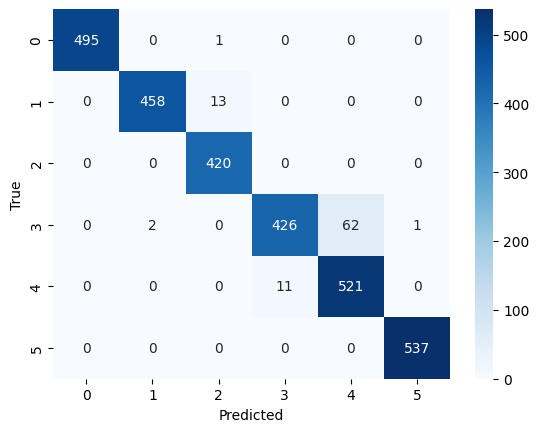

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [4]:
from torchinfo import summary
from mytorch import CNNLSTM
summary(CNNLSTM(6, 64, 0, 2), input_size=(128, 128, 9))

Layer (type:depth-idx)                   Output Shape              Param #
CNNLSTM                                  [128, 6]                  --
├─Sequential: 1-1                        [128, 64, 62]             --
│    └─Conv1d: 2-1                       [128, 64, 62]             2,944
│    └─ReLU: 2-2                         [128, 64, 62]             --
│    └─BatchNorm1d: 2-3                  [128, 64, 62]             128
├─LSTM: 1-2                              [128, 62, 128]            165,888
├─Sequential: 1-3                        [128, 6]                  --
│    └─AdaptiveAvgPool1d: 2-4            [128, 128, 1]             --
│    └─Flatten: 2-5                      [128, 128]                --
│    └─Dropout: 2-6                      [128, 128]                --
│    └─Linear: 2-7                       [128, 6]                  774
Total params: 169,734
Trainable params: 169,734
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 1.34
Input size (MB): 0.59
Forward/bac

In [5]:
summary(CNNLSTM(6, 32, 1, 1), input_size=(128, 128, 9))

C:\Users\Ur451\Desktop\SSM\.venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
CNNLSTM                                  [128, 6]                  --
├─Sequential: 1-1                        [128, 32, 62]             --
│    └─Conv1d: 2-1                       [128, 32, 62]             1,472
│    └─ReLU: 2-2                         [128, 32, 62]             --
│    └─BatchNorm1d: 2-3                  [128, 32, 62]             64
├─ModuleList: 1-2                        --                        --
│    └─ModuleDict: 2-4                   --                        --
│    │    └─Sequential: 3-1              [128, 64, 60]             6,336
│    │    └─Sequential: 3-2              [128, 64, 60]             12,480
│    │    └─Sequential: 3-3              [128, 64, 60]             4,288
├─LSTM: 1-3                              [128, 30, 128]            66,560
├─Sequential: 1-4                        [128, 6]                  --
│    └─AdaptiveAvgPool1d: 2-5            [128, 128, 1]             -

In [6]:
summary(CNNLSTM(6, 16, 3, 0), input_size=(128, 128, 9))

Layer (type:depth-idx)                   Output Shape              Param #
CNNLSTM                                  [128, 6]                  --
├─Sequential: 1-1                        [128, 16, 62]             --
│    └─Conv1d: 2-1                       [128, 16, 62]             736
│    └─ReLU: 2-2                         [128, 16, 62]             --
│    └─BatchNorm1d: 2-3                  [128, 16, 62]             32
├─ModuleList: 1-2                        --                        --
│    └─ModuleDict: 2-4                   --                        --
│    │    └─Sequential: 3-1              [128, 32, 60]             1,632
│    │    └─Sequential: 3-2              [128, 32, 60]             3,168
│    │    └─Sequential: 3-3              [128, 32, 60]             1,120
│    └─ModuleDict: 2-5                   --                        --
│    │    └─Sequential: 3-4              [128, 64, 28]             6,336
│    │    └─Sequential: 3-5              [128, 64, 28]             12,48